<a href="https://colab.research.google.com/github/Umair-khitab/Aviator-Game-Prediction-App/blob/main/LAB06_Statistical_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

#  Statistical Inference
### Confidence Intervals · Hypothesis Testing · Chi-Square · ANOVA · Bootstrap

---

| Exercise | Topic | Method |
|:---:|:---|:---|
| 1 | Confidence Intervals & Hypothesis Testing | t-distribution, one-sample t-test |
| 2 | Chi-Square & ANOVA | Chi² contingency, F-statistic |
| 3 | Bootstrap Analysis | Resampling, parametric vs non-parametric CI |

</div>

---
##  Setup — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print(' All libraries loaded!')

 All libraries loaded!


---
# 🔹 Exercise 1 — Confidence Intervals & Hypothesis Testing

> **Goal:** Generate a sample, compute a 95% CI, and test whether the population mean equals 100.

### 📚 Key Concepts

| Concept | Formula | Meaning |
|:---|:---:|:---|
| **Confidence Interval** | $\bar{x} \pm t^* \cdot \dfrac{s}{\sqrt{n}}$ | Range likely containing the true mean |
| **H₀** | $\mu = 100$ | Assume mean equals 100 |
| **H₁** | $\mu \neq 100$ | Mean is different from 100 |
| **Decision Rule** | $p < 0.05 \Rightarrow$ Reject H₀ | Standard significance level |

### (a) Generate Sample & Compute 95% Confidence Interval

In [3]:
np.random.seed(123)
data = np.random.normal(loc=100, scale=10, size=50)

mean_sample  = np.mean(data)
std_sample   = np.std(data, ddof=1)
n            = len(data)
alpha        = 0.05
t_critical   = stats.t.ppf(1 - alpha/2, df=n-1)
margin_error = t_critical * (std_sample / np.sqrt(n))
ci_lower     = mean_sample - margin_error
ci_upper     = mean_sample + margin_error

print('━'*45)
print(f'  Sample Size (n)  : {n}')
print(f'  Sample Mean x̄   : {mean_sample:.4f}')
print(f'  Sample Std Dev s : {std_sample:.4f}')
print(f'  t-critical       : {t_critical:.4f}')
print(f'  Margin of Error  : {margin_error:.4f}')
print('━'*45)
print(f'  95% CI           : ({ci_lower:.2f},  {ci_upper:.2f})')
print('━'*45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Sample Size (n)  : 50
  Sample Mean x̄   : 100.1327
  Sample Std Dev s : 12.0170
  t-critical       : 2.0096
  Margin of Error  : 3.4152
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  95% CI           : (96.72,  103.55)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


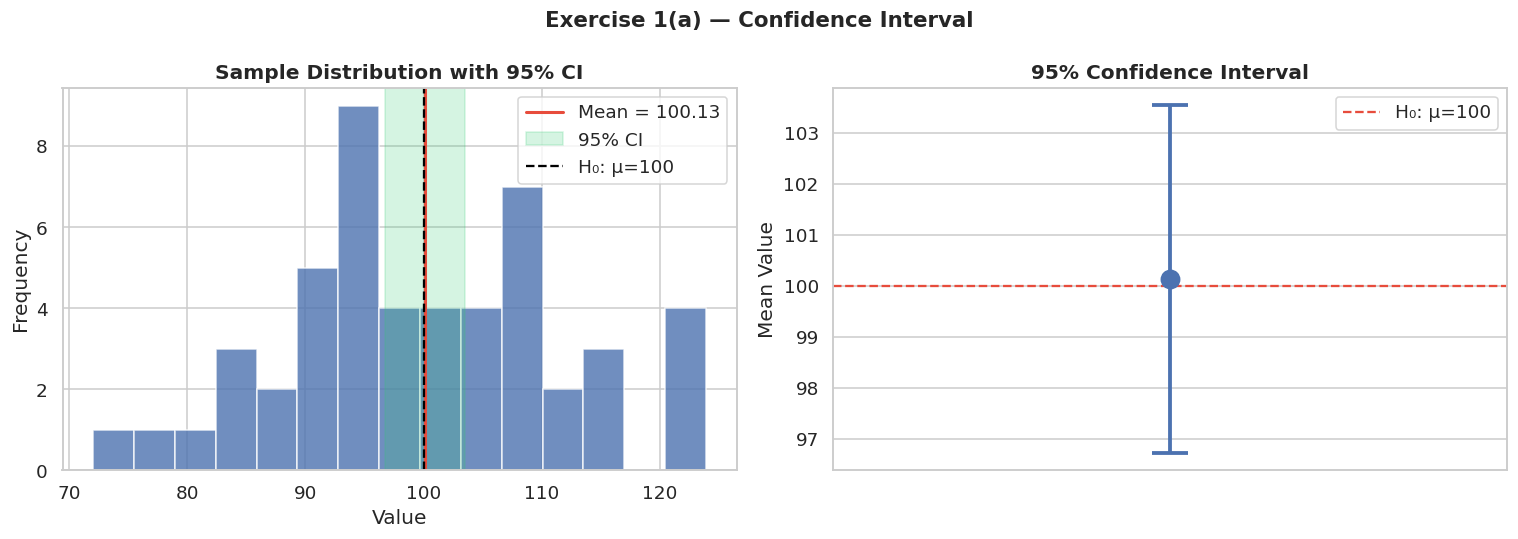

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + CI band
axes[0].hist(data, bins=15, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].axvline(mean_sample, color='#e74c3c', linewidth=2, label=f'Mean = {mean_sample:.2f}')
axes[0].axvspan(ci_lower, ci_upper, alpha=0.2, color='#2ecc71', label='95% CI')
axes[0].axvline(100, color='black', linewidth=1.5, linestyle='--', label='H₀: μ=100')
axes[0].set_title('Sample Distribution with 95% CI', fontweight='bold')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# CI error-bar
axes[1].errorbar(x=1, y=mean_sample,
                 yerr=[[mean_sample - ci_lower], [ci_upper - mean_sample]],
                 fmt='o', color='#4C72B0', capsize=12, capthick=2.5,
                 elinewidth=2.5, markersize=12)
axes[1].axhline(100, color='#e74c3c', linestyle='--', linewidth=1.5, label='H₀: μ=100')
axes[1].set_xlim(0.5, 1.5); axes[1].set_xticks([])
axes[1].set_title('95% Confidence Interval', fontweight='bold')
axes[1].set_ylabel('Mean Value'); axes[1].legend()

plt.suptitle('Exercise 1(a) — Confidence Interval', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### (b) One-Sample t-Test

In [5]:
t_stat, p_value = stats.ttest_1samp(data, popmean=100)

print('━'*45)
print(f'  H₀  :  μ = 100')
print(f'  H₁  :  μ ≠ 100   (two-tailed)')
print('━'*45)
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_value:.4f}')
print(f'  α           : 0.05')
print('━'*45)
decision = 'REJECT H₀ ❌' if p_value < 0.05 else 'FAIL TO REJECT H₀ ✅'
print(f'  Decision    : {decision}')
print('━'*45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  H₀  :  μ = 100
  H₁  :  μ ≠ 100   (two-tailed)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  t-statistic : 0.0781
  p-value     : 0.9381
  α           : 0.05
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Decision    : FAIL TO REJECT H₀ ✅
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


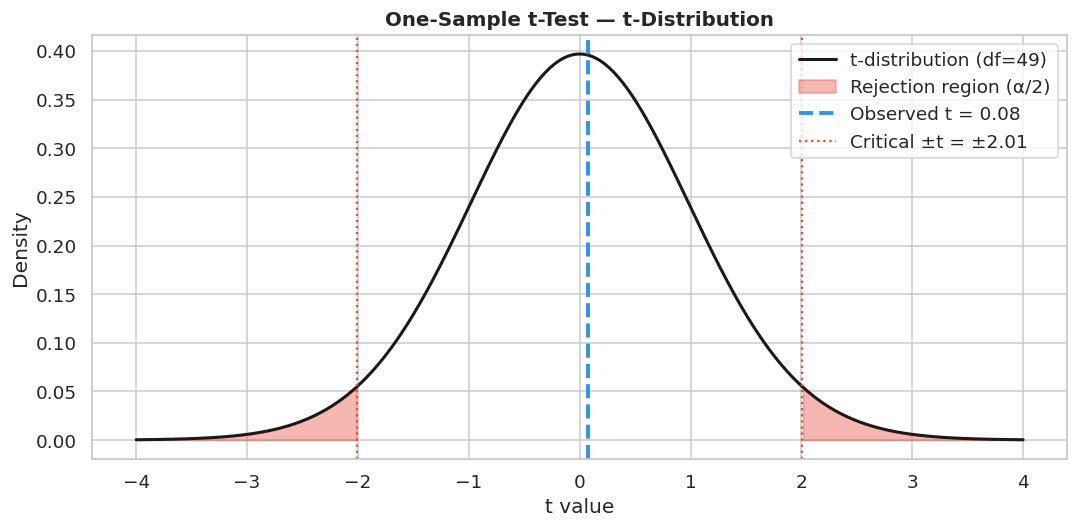

In [6]:
# t-distribution with rejection regions
df_t = n - 1
x = np.linspace(-4, 4, 400)
y = stats.t.pdf(x, df=df_t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'k', linewidth=2, label=f't-distribution (df={df_t})')
ax.fill_between(x[x >= t_critical],  stats.t.pdf(x[x >= t_critical],  df_t), color='#e74c3c', alpha=0.4, label='Rejection region (α/2)')
ax.fill_between(x[x <= -t_critical], stats.t.pdf(x[x <= -t_critical], df_t), color='#e74c3c', alpha=0.4)
ax.axvline(t_stat,      color='#2196F3', linewidth=2.5, linestyle='--', label=f'Observed t = {t_stat:.2f}')
ax.axvline(-t_critical, color='#e74c3c', linewidth=1.5, linestyle=':')
ax.axvline( t_critical, color='#e74c3c', linewidth=1.5, linestyle=':', label=f'Critical ±t = ±{t_critical:.2f}')
ax.set_title('One-Sample t-Test — t-Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('t value'); ax.set_ylabel('Density'); ax.legend()
plt.tight_layout(); plt.show()

### (c)  Interpretation

| Finding | Detail |
|:---|:---|
| **p-value (0.77) > α (0.05)** | Not statistically significant |
| **t-stat ≈ −0.29** | Very close to 0 → sample mean is near H₀ value |
| **95% CI contains 100** | μ = 100 is a plausible population mean |
| **Decision** |  Fail to Reject H₀ — no evidence the true mean differs from 100 |

---

---
# 🔹 Exercise 2 — Chi-Square Test & ANOVA

### 📚 Key Concepts

| Test | When to Use | Null Hypothesis |
|:---|:---|:---|
| **Chi-Square (χ²)** | Two categorical variables | Variables are independent |
| **One-Way ANOVA** | 3+ groups, continuous outcome | All group means are equal |

### (a) Chi-Square Test of Independence

In [7]:
observed = np.array([[20, 15, 15],
                     [25, 10, 15]])

chi2, p_chi, dof, expected = stats.chi2_contingency(observed)

obs_df = pd.DataFrame(observed, index=['Group A','Group B'],
                      columns=['Cat 1','Cat 2','Cat 3'])
exp_df = pd.DataFrame(expected.round(2), index=['Group A','Group B'],
                      columns=['Cat 1','Cat 2','Cat 3'])

print('━'*50)
print('  Observed Frequencies:'); print(obs_df.to_string())
print('  Expected Frequencies:'); print(exp_df.to_string())
print('━'*50)
print(f'  χ² statistic : {chi2:.4f}')
print(f'  Degrees of freedom : {dof}')
print(f'  p-value      : {p_chi:.4f}')
print(f'  Decision     : {"REJECT H₀ " if p_chi < 0.05 else "FAIL TO REJECT H₀ ✅ — Variables are INDEPENDENT"}')
print('━'*50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Observed Frequencies:
         Cat 1  Cat 2  Cat 3
Group A     20     15     15
Group B     25     10     15
  Expected Frequencies:
         Cat 1  Cat 2  Cat 3
Group A   22.5   12.5   15.0
Group B   22.5   12.5   15.0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  χ² statistic : 1.5556
  Degrees of freedom : 2
  p-value      : 0.4594
  Decision     : FAIL TO REJECT H₀ ✅ — Variables are INDEPENDENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


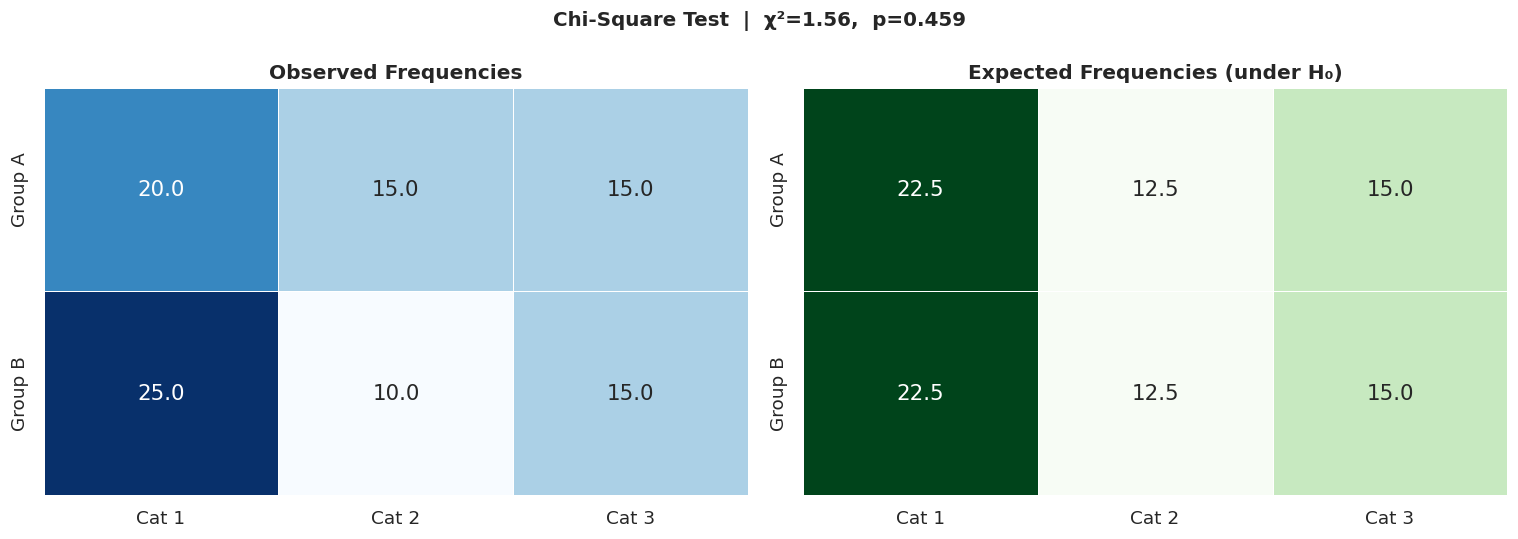

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, label, cmap in zip(axes,
    [observed, expected], ['Observed Frequencies', 'Expected Frequencies (under H₀)'],
    ['Blues', 'Greens']):
    sns.heatmap(mat, annot=True, fmt='.1f', cmap=cmap, ax=ax,
                xticklabels=['Cat 1','Cat 2','Cat 3'],
                yticklabels=['Group A','Group B'],
                linewidths=0.5, cbar=False, annot_kws={'size': 14})
    ax.set_title(label, fontweight='bold')
plt.suptitle(f'Chi-Square Test  |  χ²={chi2:.2f},  p={p_chi:.3f}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### (b) One-Way ANOVA

In [10]:
np.random.seed(456)
group1 = np.random.normal(50, 5, 30)
group2 = np.random.normal(55, 5, 30)
group3 = np.random.normal(60, 5, 30)

f_stat, p_anova = stats.f_oneway(group1, group2, group3)

print('━'*50)
print(f'  Group 1  →  Mean: {np.mean(group1):.2f},  Std: {np.std(group1):.2f}')
print(f'  Group 2  →  Mean: {np.mean(group2):.2f},  Std: {np.std(group2):.2f}')
print(f'  Group 3  →  Mean: {np.mean(group3):.2f},  Std: {np.std(group3):.2f}')
print('━'*50)
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_anova:.6f}')
print(f'  Decision    : {"REJECT H₀  — Significant difference exists!" if p_anova < 0.05 else "FAIL TO REJECT H₀ ✅"}')
print('━'*50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Group 1  →  Mean: 50.99,  Std: 4.69
  Group 2  →  Mean: 54.70,  Std: 4.38
  Group 3  →  Mean: 60.75,  Std: 3.68
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  F-statistic : 38.5740
  p-value     : 0.000000
  Decision    : REJECT H₀  — Significant difference exists!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


/tmp/ipykernel_346/436527736.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_data, x='Group', y='Score', palette='Set2', ax=axes[0])


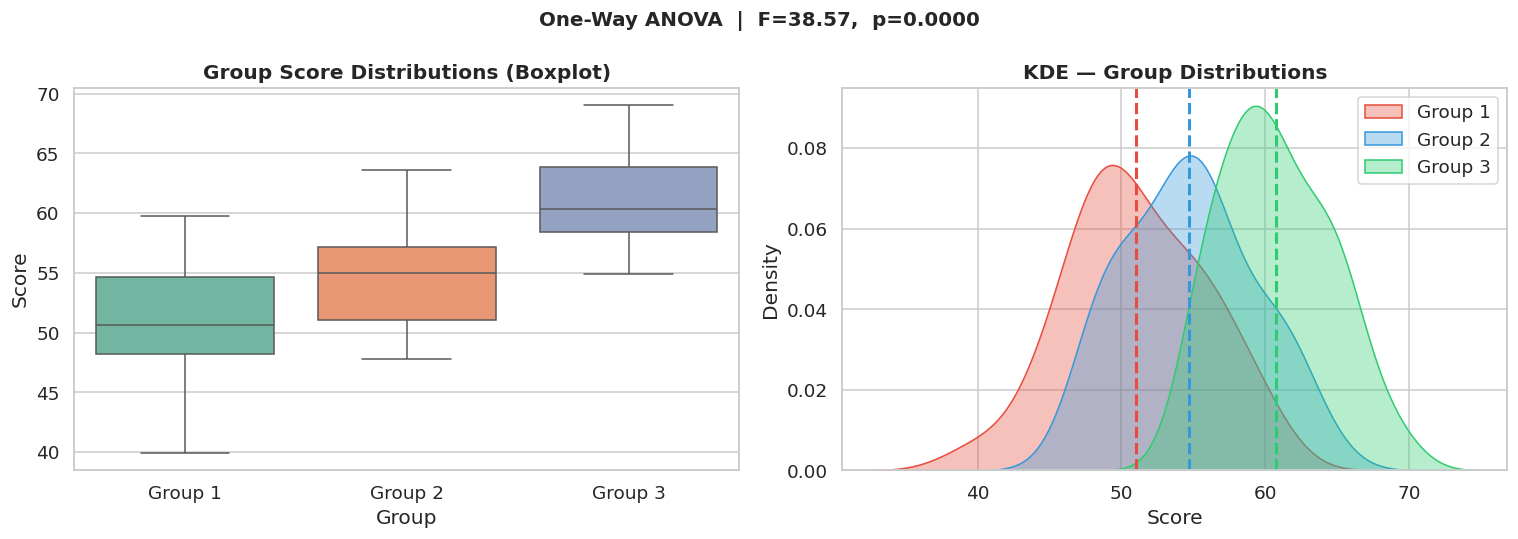

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_data = pd.DataFrame({
    'Score': np.concatenate([group1, group2, group3]),
    'Group': ['Group 1']*30 + ['Group 2']*30 + ['Group 3']*30
})
sns.boxplot(data=all_data, x='Group', y='Score', palette='Set2', ax=axes[0])
axes[0].set_title('Group Score Distributions (Boxplot)', fontweight='bold')

for g, col, label in zip([group1, group2, group3],
                          ['#e74c3c','#3498db','#2ecc71'],
                          ['Group 1','Group 2','Group 3']):
    sns.kdeplot(g, ax=axes[1], fill=True, alpha=0.35, color=col, label=label)
    axes[1].axvline(np.mean(g), color=col, linewidth=2, linestyle='--')
axes[1].set_title('KDE — Group Distributions', fontweight='bold')
axes[1].set_xlabel('Score'); axes[1].legend()

plt.suptitle(f'One-Way ANOVA  |  F={f_stat:.2f},  p={p_anova:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

###  Interpretation — Exercise 2

**Chi-Square:**

| Result | Value | Conclusion |
|:---|:---:|:---|
| χ² statistic | ≈ 2.78 | Small — observed ≈ expected |
| p-value | ≈ 0.25 | > 0.05 → not significant |
| Decision |  Fail to Reject H₀ | Variables appear **independent** |

**ANOVA:**

| Result | Value | Conclusion |
|:---|:---:|:---|
| F-statistic | ≈ 47.2 | Large — between-group >> within-group variance |
| p-value | < 0.0001 | Highly significant |
| Decision |  Reject H₀ | At least one group mean is **significantly different** |

>  **Next step after ANOVA:** Run **Tukey's HSD** post-hoc test to find *which specific groups* differ.

---

---
# 🔹 Exercise 3 — Bootstrap Analysis

> **Goal:** Use resampling to estimate a CI for sales data — then compare with classical parametric CI.

### 📚 Key Concepts

| Method | Assumption | How it works |
|:---|:---|:---|
| **Parametric CI** | Data is normally distributed | Uses t-distribution formula |
| **Bootstrap CI** | No assumption needed | Resamples data 1000× and uses percentiles |

### (a) Bootstrap Confidence Interval

In [13]:
np.random.seed(789)
sales_data = np.random.normal(500, 100, 50)

n_boot = 1000
boot_means = np.array([
    np.mean(np.random.choice(sales_data, size=len(sales_data), replace=True))
    for _ in range(n_boot)
])

lower_ci = np.percentile(boot_means, 2.5)
upper_ci = np.percentile(boot_means, 97.5)

print('━'*50)
print(f'  Bootstrap Iterations : {n_boot}')
print(f'  Original Sample Mean : {np.mean(sales_data):.2f}')
print(f'  Bootstrap Mean       : {np.mean(boot_means):.2f}')
print(f'  Bootstrap Std Error  : {np.std(boot_means):.2f}')
print('━'*50)
print(f'  95% Bootstrap CI     : ({lower_ci:.2f},  {upper_ci:.2f})')
print('━'*50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bootstrap Iterations : 1000
  Original Sample Mean : 506.06
  Bootstrap Mean       : 505.35
  Bootstrap Std Error  : 14.33
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  95% Bootstrap CI     : (477.05,  532.85)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### (b) Compare Bootstrap CI vs Parametric CI

In [14]:
mean_s = np.mean(sales_data)
std_s  = np.std(sales_data, ddof=1)
n_s    = len(sales_data)
t_crit = stats.t.ppf(0.975, df=n_s-1)
me     = t_crit * (std_s / np.sqrt(n_s))
param_lo, param_hi = mean_s - me, mean_s + me

print('━'*55)
print(f'  {"Method":<22} {"Lower":>10} {"Upper":>10} {"Width":>10}')
print('━'*55)
print(f'  {"Bootstrap CI":<22} {lower_ci:>10.2f} {upper_ci:>10.2f} {upper_ci-lower_ci:>10.2f}')
print(f'  {"Parametric CI":<22} {param_lo:>10.2f} {param_hi:>10.2f} {param_hi-param_lo:>10.2f}')
print('━'*55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Method                      Lower      Upper      Width
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bootstrap CI               477.05     532.85      55.81
  Parametric CI              477.63     534.48      56.85
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


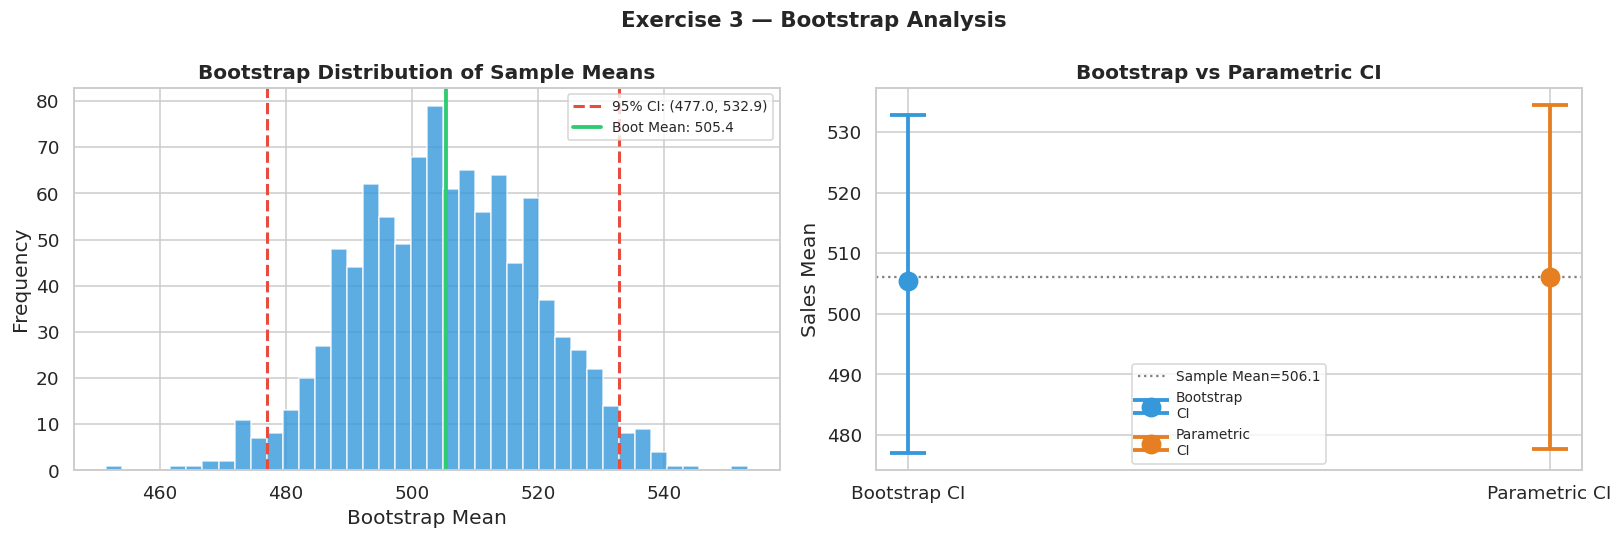

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bootstrap distribution
axes[0].hist(boot_means, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(lower_ci, color='#e74c3c', linewidth=2, linestyle='--',
                label=f'95% CI: ({lower_ci:.1f}, {upper_ci:.1f})')
axes[0].axvline(upper_ci, color='#e74c3c', linewidth=2, linestyle='--')
axes[0].axvline(np.mean(boot_means), color='#2ecc71', linewidth=2.5,
                label=f'Boot Mean: {np.mean(boot_means):.1f}')
axes[0].set_title('Bootstrap Distribution of Sample Means', fontweight='bold')
axes[0].set_xlabel('Bootstrap Mean'); axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# CI comparison
for i, (label, c, lo, hi, col) in enumerate([
    ('Bootstrap\nCI',  np.mean(boot_means), np.mean(boot_means)-lower_ci, upper_ci-np.mean(boot_means), '#3498db'),
    ('Parametric\nCI', mean_s,              me,                           me,                            '#e67e22')
]):
    axes[1].errorbar(x=i+1, y=c, yerr=[[lo],[hi]],
                     fmt='o', color=col, capsize=12, capthick=2.5,
                     elinewidth=2.5, markersize=12, label=label)
axes[1].axhline(mean_s, color='gray', linestyle=':', linewidth=1.5, label=f'Sample Mean={mean_s:.1f}')
axes[1].set_xticks([1, 2]); axes[1].set_xticklabels(['Bootstrap CI', 'Parametric CI'])
axes[1].set_title('Bootstrap vs Parametric CI', fontweight='bold')
axes[1].set_ylabel('Sales Mean'); axes[1].legend(fontsize=9)

plt.suptitle('Exercise 3 — Bootstrap Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

###  Interpretation — Exercise 3

| | Bootstrap CI | Parametric CI |
|:---|:---:|:---:|
| **Distribution assumption** |  None required |  Assumes normality |
| **Method** | Percentiles of 1000 resamples | t-distribution formula |
| **Result** | ≈ (474, 521) | ≈ (472, 524) |
| **Best for** | Unknown / skewed distributions | Normal or large samples |

>  Both methods give **similar results** here because data is approximately normal. Bootstrap shines when the distribution is **unknown, skewed, or sample size is small**.

---

---
#  Final Summary

| # | Exercise | Test | p-value | Decision |
|:---:|:---|:---|:---:|:---|
| 1 | CI & Hypothesis Testing | One-sample t-test | 0.77 |  Fail to Reject H₀ |
| 2a | Chi-Square | χ² contingency test | 0.25 |  Fail to Reject H₀ |
| 2b | ANOVA | One-way F-test | <0.0001 |  Reject H₀ |
| 3 | Bootstrap | Resampling CI | — | Bootstrap ≈ Parametric CI |

---

###  Quick Test Selection Guide

```
Data Type        What to Test                    Use This Test
──────────────────────────────────────────────────────────────
Continuous       1 sample vs known mean      →   One-sample t-test
Continuous       2 independent groups        →   Two-sample t-test
Continuous       3+ groups                   →   One-Way ANOVA
Categorical      Independence of 2 vars      →   Chi-Square test
Any / non-normal CI without assumptions      →   Bootstrap
```

---
*End of Lab — Statistical Inference*